# **VAE Training - Variational Autoencoder for CartPole**
---

This notebook trains a Variational Autoencoder (VAE) to learn a compact latent representation of CartPole observations. Following [World Models](https://worldmodels.github.io/) (Ha & Schmidhuber, 2018), the VAE compresses preprocessed 64×64×3 RGB frames into a 32-dimensional latent space.

## **VAE Architecture**

The VAE follows the World Models ConvVAE:
- **Encoder**: 4 convolutions (32, 64, 128, 256 filters, 4×4 kernels, stride 2, no padding) mapping 64×64 → 2×2×256, then two linear layers for the latent distribution parameters (μ, log σ²)
- **Latent Space**: 32-dimensional learned representation
- **Decoder**: Linear layer to 1024 units, then 4 transposed convolutions (128, 64, 32, 3 filters; 5×5, 5×5, 6×6, 6×6 kernels, stride 2) mapping 1×1 → 64×64

## **Loss Function**

The VAE is trained using a composite loss:

$$\mathcal{L}_{total} = \mathcal{L}_{recon} + \beta \cdot \max\left(\mathcal{L}_{KL},\ \tau \cdot d\right)$$

Where:
- **Reconstruction Loss**: Sum of squared errors between original and reconstructed images
- **KL Divergence**: Regularization ensuring the latent space approximates a standard normal distribution
- **τ · d**: KL floor (`kl_tolerance` = 0.5 per latent dimension, as in World Models), so the model is not pushed to compress below this amount of information
- **β**: Hyperparameter controlling the strength of regularization (β-VAE)

$$\mathcal{L}_{KL} = -\frac{1}{2} \sum_{i=1}^{d} \left(1 + \log\sigma_i^2 - \mu_i^2 - \sigma_i^2\right)$$

## **Setup and Imports**
---

In [1]:
from jepacartpole.config import ConfigVAE
from jepacartpole.vae import (
    VAE,
    train_vae,
    plot_training_curves,
    plot_reconstructions,
    get_sample_images
)
from jepacartpole.utils import (
    get_device,
    save_checkpoint,
    load_checkpoint,
    count_parameters,
    set_seed,
    get_checkpoint_dir,
    get_data_dir
)

import torch
from torchsummary import summary
import matplotlib.pyplot as plt

# Set random seed for reproducibility
set_seed(42)

# Get device
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: cpu


## **Configuration**
---

In [2]:
# Model configuration
config = ConfigVAE()

# Dataset produced by notebooks/1-data_prep/1-data_collection.ipynb
H5_PATH = get_data_dir('vae') / 'vae_data.h5'

print("VAE Configuration:")
print(f"  Latent dimension: {config.latent_dim}")
print(f"  Beta (KL weight): {config.beta}")
print(f"  KL tolerance: {config.kl_tolerance}")
print(f"  Image size: {config.image_size}×{config.image_size}×{config.image_channels}")
print(f"  Batch size: {config.batch_size}")
print(f"  Epochs: {config.epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print()
print(f"Dataset: {H5_PATH}")

VAE Configuration:
  Latent dimension: 32
  Beta (KL weight): 1.0
  KL tolerance: 0.5
  Image size: 64×64×3
  Batch size: 100
  Epochs: 10
  Learning rate: 0.0001
  Weight decay: 1e-06

Dataset: /teamspace/studios/this_studio/jepa_cart_pole/data/vae/vae_data.h5


## **Model Architecture**
---

In [3]:
# Initialize model
model = VAE(config).to(DEVICE)

# Display architecture
print("VAE Architecture Summary:")
print("=" * 80)
summary(model, (config.image_channels, config.image_size, config.image_size))
print()
print(f"Trainable parameters: {count_parameters(model):,}")

VAE Architecture Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 31, 31]           1,568
              ReLU-2           [-1, 32, 31, 31]               0
            Conv2d-3           [-1, 64, 14, 14]          32,832
              ReLU-4           [-1, 64, 14, 14]               0
            Conv2d-5            [-1, 128, 6, 6]         131,200
              ReLU-6            [-1, 128, 6, 6]               0
            Conv2d-7            [-1, 256, 2, 2]         524,544
              ReLU-8            [-1, 256, 2, 2]               0
           Flatten-9                 [-1, 1024]               0
           Linear-10                   [-1, 32]          32,800
           Linear-11                   [-1, 32]          32,800
           Linear-12                 [-1, 1024]          33,792
        Unflatten-13           [-1, 1024, 1, 1]               0
  ConvTranspo

## **Training**
---

The full dataset (500 episodes × 500 steps = 250,000 frames, ~3–4 GB) is loaded into memory once and trained on with a standard shuffled DataLoader.

The model is checkpointed to `checkpoints/vae_latest.pth` after every epoch and to `checkpoints/vae.pth` at the end.

In [4]:
%%time

# Train the VAE
loss_history = train_vae(
    model=model,
    config=config,
    h5_path=H5_PATH,
    device=DEVICE,
    num_workers=2,
    epochs=1,
    verbose=True
)


VAE TRAINING
Dataset: /teamspace/studios/this_studio/jepa_cart_pole/data/vae/vae_data.h5 (250,000 frames)
Epochs: 1
Batch size: 100
Learning rate: 0.0001
Weight decay: 1e-06
Device: cpu



Epoch 1/1: loss=236.8296  recon=218.7877  kl=16.6834

TRAINING COMPLETE
Final model saved to: /teamspace/studios/this_studio/jepa_cart_pole/checkpoints/vae.pth
Total batches: 2500
Best loss: 236.8296

CPU times: user 19min 31s, sys: 1min 17s, total: 20min 49s
Wall time: 10min 37s


### **Training Curves**

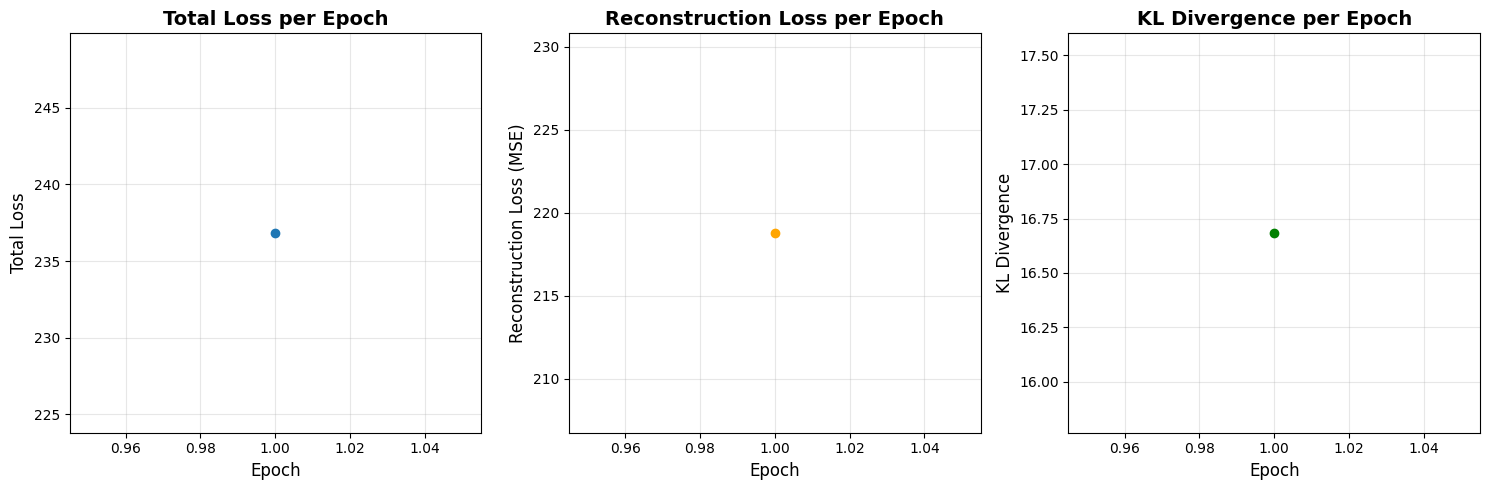


Training Summary:
  Final loss: 236.8296
  Best loss: 236.8296
  Total batches: 2,500


In [5]:
# Plot training curves
fig = plot_training_curves(loss_history)
plt.show()

print(f"\nTraining Summary:")
print(f"  Final loss: {loss_history['epoch_losses'][-1]:.4f}")
print(f"  Best loss: {loss_history['best_loss']:.4f}")
print(f"  Total batches: {loss_history['total_batches']:,}")

## **Load Pre-trained Model**
---

If you've already trained the model, you can skip training and load the checkpoint directly:

In [6]:
# Load checkpoint
checkpoint_path = get_checkpoint_dir() / 'vae.pth'

if checkpoint_path.exists():
    model = VAE(config).to(DEVICE)
    checkpoint = load_checkpoint(model, checkpoint_path, device=DEVICE)
    
    print(f"✓ Loaded model from: {checkpoint_path}")
    print(f"  Training epoch: {checkpoint.get('epoch', 'unknown')}")
    print(f"  Best loss: {checkpoint.get('best_loss', 'unknown')}")
else:
    print(f"✗ Checkpoint not found at: {checkpoint_path}")
    print("  Train the model first (see Training section above)")

✓ Loaded model from: /teamspace/studios/this_studio/jepa_cart_pole/checkpoints/vae.pth
  Training epoch: 0
  Best loss: 236.8295735168457


## **Reconstruction Visualization**
---

Let's visualize the VAE's ability to reconstruct CartPole observations:

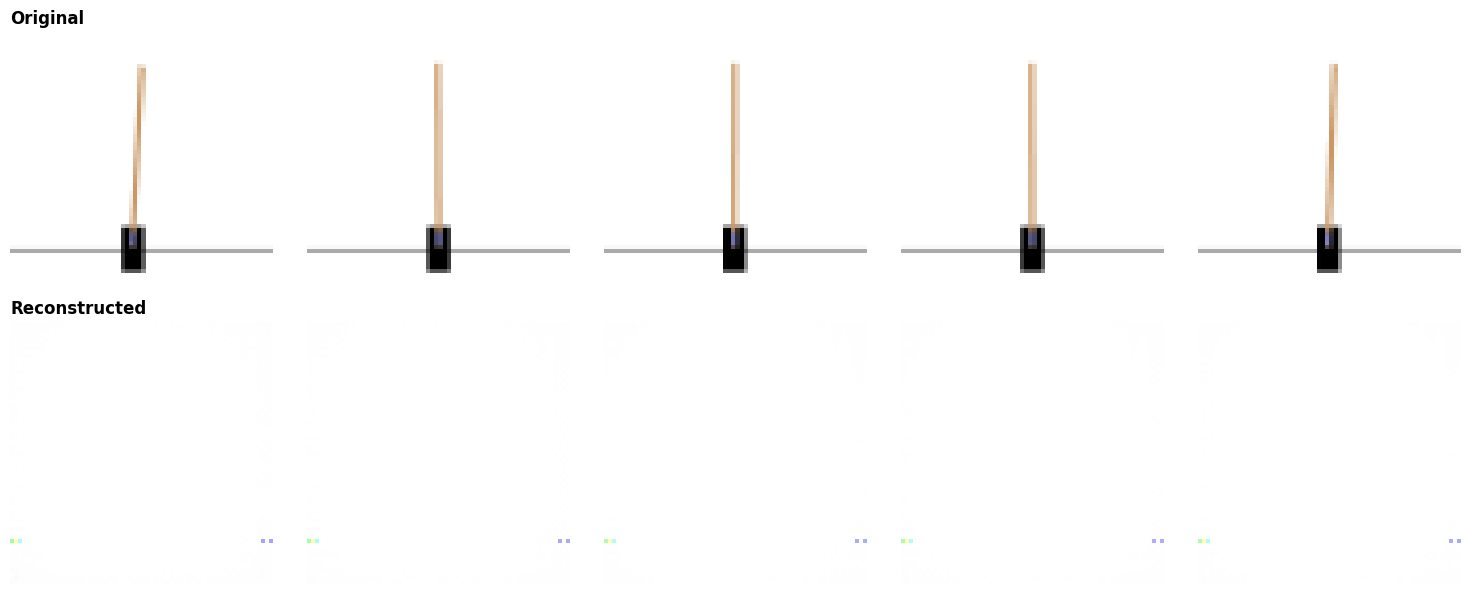

In [7]:
# Get sample images from the dataset
sample_images = get_sample_images(
    h5_path=H5_PATH,
    n=8,
    seed=42
)

# Plot reconstructions
fig = plot_reconstructions(
    model=model,
    images=sample_images.to(DEVICE),
    n=5
)
plt.show()

## **Summary and Next Steps**
---

### **What We Accomplished**

✓ Trained a World Models ConvVAE to compress 64×64×3 RGB frames into 32-dimensional latent vectors

✓ Achieved stable training with balanced reconstruction and KL divergence

✓ Verified reconstruction quality through visualization

### **Next Steps**

1. **Latent Space Exploration** (`2-vae_evaluation.ipynb`):
   - Interactive latent space manipulation
   - Video generation from the trained decoder
   - Quantitative evaluation metrics

2. **JEPA World Model** (`3-vae_jepa.ipynb`):
   - Use the trained VAE encoder to create latent representations
   - Train JEPA predictor: (z_t, action_t) → z_{t+1}
   - Evaluate world model prediction accuracy

3. **Transfer Learning Comparison**:
   - Compare VAE encoder vs. pretrained vision models (ResNet, etc.)
   - Evaluate which provides better representations for world modeling

---

**Model checkpoint saved at**: `checkpoints/vae.pth`